In [3]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.utils import to_categorical  # Import to_categorical directly
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

# Now you can use to_categorical like this:
# y_encoded = to_categorical(y_labels)

In [4]:
seed = 9
np.random.seed(seed)

In [5]:
# load datasets
#csv files were filtered based on the data.
input_file = "filtereddata.txt"
test_file = "filtereddata.txt"

In [6]:
dataset = pd.read_csv(input_file).values

In [7]:
# read training data
datasetTest = pd.read_csv(test_file).values

# split into input (X) and output (Y) variables
X = dataset[:,0:8].astype("int32")
Y = dataset[:,8]
XT = datasetTest[:,0:8].astype("int32")

In [8]:
encoder=LabelEncoder()
encoder.fit(Y)
encoded_Y=encoder.transform(Y)

In [9]:
# convert integers to dummy variables (i.e. one hot encoded)
dummy_y = to_categorical(encoded_Y)

In [10]:
(X_train, X_test, Y_train, Y_test) = train_test_split(X, dummy_y, test_size=0.001, random_state=seed)

In [13]:
# create model
model = Sequential()
model.add(Dense(8, input_dim=8, kernel_initializer='normal', activation='relu'))
model.add(Dense(4, kernel_initializer='normal', activation='relu'))
model.add(Dense(3, kernel_initializer='normal', activation='tanh'))
model.add(Dense(3, kernel_initializer='normal', activation='softmax'))
print(model.summary())
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 3)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 135 (540.00 B)

 Trainable params: 135 (540.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
# Fit the model
history = model.fit(X_train, Y_train, validation_split=0.3, epochs=16, batch_size=128)

Epoch 1/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5343 - loss: 0.9991 - val_accuracy: 0.7116 - val_loss: 0.6725
Epoch 2/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7364 - loss: 0.6212 - val_accuracy: 0.8229 - val_loss: 0.4815
Epoch 3/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8571 - loss: 0.4510 - val_accuracy: 0.9375 - val_loss: 0.3717
Epoch 4/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9394 - loss: 0.3481 - val_accuracy: 0.9413 - val_loss: 0.2989
Epoch 5/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9536 - loss: 0.2576 - val_accuracy: 1.0000 - val_loss: 0.0942
Epoch 6/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0802 - val_accuracy: 1.0000 - val_loss: 0.0508
Epoch 7/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0450 - val_accuracy: 1.0000 - val_loss: 0.0324
Epoch 8/16
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0292 - val_accuracy: 1.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0033 

compile_metrics: 100.00%


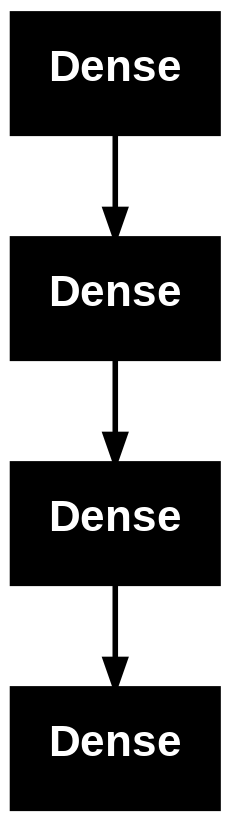

In [15]:
# evaluate the model
scores = model.evaluate(X_test, Y_test)

print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

plot_model(model, to_file='model.png')

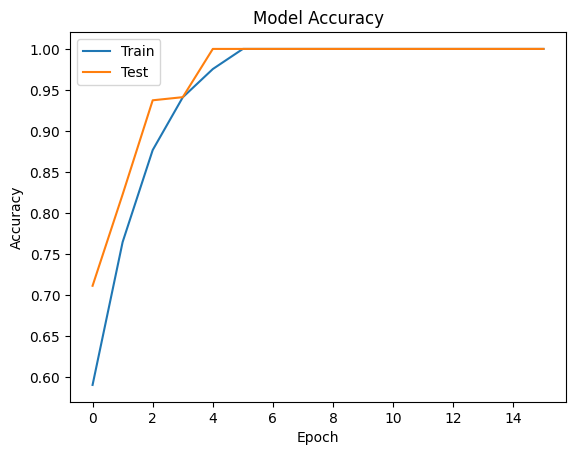

In [17]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

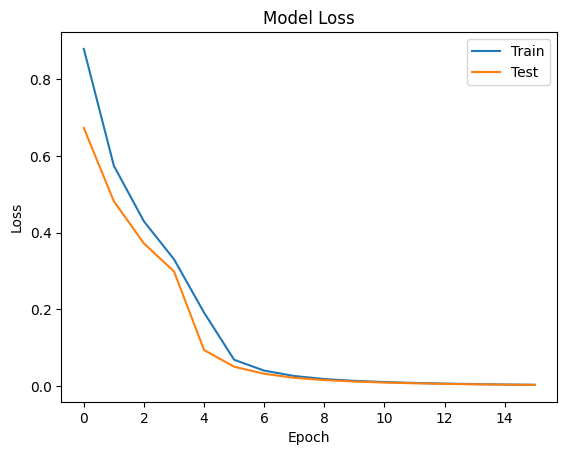

In [18]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()